In [4]:
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")

configs = [
    ("Test_Phieu_01", "Kiemtra_bangmatthuong_test01.txt"),
    ("Test_Phieu_02", "Kiemtra_bangmatthuong_test02.txt"),
]

for sheet_id, txt_file in configs:
    txt_path = BASE / sheet_id / txt_file
    labels_raw = txt_path.read_text(encoding="utf-8").strip().splitlines()

    records = []
    for i, label in enumerate(labels_raw, start=1):
        label_clean = label.strip().replace(",", ".")
        if label_clean.upper() == "NAN":
            score = float("nan")
        else:
            score = float(label_clean)
        
        img_path = BASE / sheet_id / "preprocessed" / f"stt_{i:02d}.png"
        records.append({
            "sheet": sheet_id,
            "stt": i,
            "image_path": str(img_path),
            "label": score
        })

    df = pd.DataFrame(records)
    out_path = BASE / sheet_id / "external_test_labels.csv"
    df.to_csv(out_path, index=False)

    print(f"{sheet_id}: {len(df)} samples | NaN: {df['label'].isna().sum()}")
    print(df['label'].value_counts().sort_index(), "\n")

Test_Phieu_01: 45 samples | NaN: 2
label
6.5    7
6.8    4
7.0    4
7.3    3
7.5    7
7.8    6
8.0    1
8.3    4
8.5    7
Name: count, dtype: int64 

Test_Phieu_02: 33 samples | NaN: 1
label
5.0    4
6.0    3
7.5    5
8.0    8
8.5    6
9.5    6
Name: count, dtype: int64 



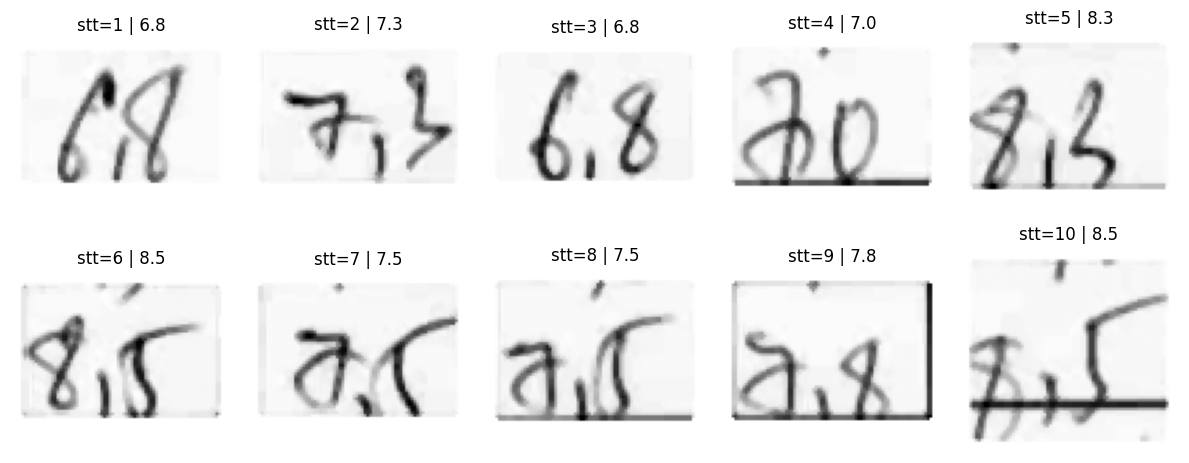

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")

df = pd.read_csv(BASE / "Test_Phieu_01" / "external_test_labels.csv")
df_valid = df.dropna(subset=["label"]).head(10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, (_, row) in zip(axes.flatten(), df_valid.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"stt={int(row['stt'])} | {row['label']}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(BASE / "reports" / "figures" / "external_test_verify.png", dpi=100)
plt.show()

# Tải từ kaggle về

In [6]:
import os
from pathlib import Path

BASE = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")
os.environ["KAGGLE_CONFIG_DIR"] = str(Path.home())

kaggle_out = BASE / "data" / "raw" / "kaggle_digits"

!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9 \
    -p "{kaggle_out}" --unzip --quiet

print("Done. Files:")
for d in sorted(kaggle_out.iterdir()):
    if d.is_dir():
        count = len(list(d.glob("*")))
        print(f"  {d.name}: {count} files")

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
Done. Files:
  0: 2236 files
  1: 2241 files
  2: 2233 files
  3: 2202 files
  4: 2179 files
  5: 2126 files
  6: 2121 files
  7: 2116 files
  8: 2085 files
  9: 2016 files


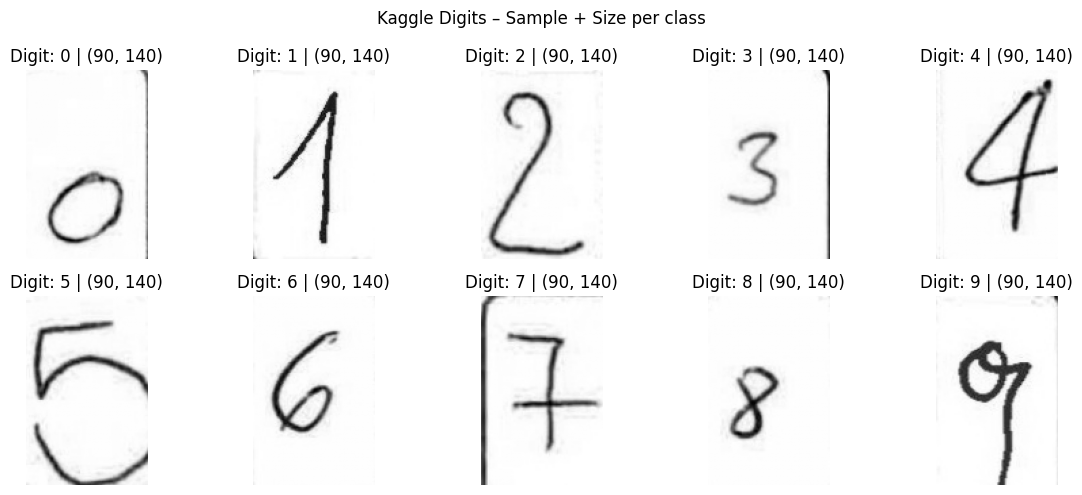

In [7]:
import random
from PIL import Image
import matplotlib.pyplot as plt

kaggle_out = BASE / "data" / "raw" / "kaggle_digits"

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, class_dir in enumerate(sorted(kaggle_out.iterdir())):
    if not class_dir.is_dir():
        continue
    imgs = list(class_dir.glob("*.png")) + list(class_dir.glob("*.jpg"))
    sample = Image.open(random.choice(imgs)).convert("L")
    axes.flatten()[i].imshow(sample, cmap="gray")
    axes.flatten()[i].set_title(f"Digit: {class_dir.name} | {sample.size}")
    axes.flatten()[i].axis("off")

plt.suptitle("Kaggle Digits – Sample + Size per class")
plt.tight_layout()
plt.savefig(BASE / "reports" / "figures" / "kaggle_sample.png", dpi=100)
plt.show()

In [8]:
audit = f"""
# Audit Log
## Kaggle Digits
- 21,555 ảnh, 10 class, balanced
- Kích thước: 90x140px, nền trắng, 1 chữ số đơn
- KHÔNG dùng train thẳng → phải qua synthetic generation

## External Test Set (LOCKED)
- Phiếu 01: 43 valid + 2 NaN = 45 samples
- Phiếu 02: 32 valid + 1 NaN = 33 samples
- Tổng: 75 ô thật có label
- Đặc điểm: 2 chữ số + dấu phẩy, có đường kẻ, blur nhẹ

## Gap cần synthetic giải quyết
- Resize về dạng ngang (~128x64)
- Ghép 2 digits + dấu phẩy thành 1 cụm
- Thêm đường kẻ bảng
- Thêm nhiễu scan, blur, contrast
- Dấu phẩy phải mô phỏng viết tay
"""

with open(BASE / "reports" / "audit_log.md", "w", encoding="utf-8") as f:
    f.write(audit)
print("Audit log saved. Notebook 00 DONE.")

Audit log saved. Notebook 00 DONE.
